In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
#%load_ext line_profiler
#%load_ext snakeviz
%autoreload 2

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import corner

import pickle

import enterprise
from enterprise.pulsar import Pulsar
import enterprise.signals.parameter as parameter
from enterprise.signals import utils
from enterprise.signals import signal_base
from enterprise.signals import selections
from enterprise.signals.selections import Selection
from enterprise.signals import white_signals
from enterprise.signals import gp_signals
from enterprise.signals import deterministic_signals
import enterprise.constants as const

from enterprise_extensions import deterministic

from scipy.stats import norm

import libstempo as T2
import libstempo.toasim as LT
import libstempo.plot as LP

import glob
import json
import h5py
import healpy as hp
import scipy.constants as sc
import emcee

from numba.typed import List

import sys
import h5py
from enterprise_extensions import model_utils

In [2]:
#COMMENT IF OUTFILE GENERATED
#Thinning script for one source
i = "/scratch/na00078/old_QuickCW/QuickCW_MDC_Group2/results/MDC_G2_D1_broad_freq_UL_outfile.h5"

infile = i
first_n_param = 8
# outfile = '/scratch/na00078/QuickCW_targeted_runs/results/3C66B_outfile.h5'

print(infile)
print(first_n_param)

with h5py.File(infile, 'r') as f:
    Ts = f['T-ladder'][...]
    samples_cold = f['samples_cold'][:,:,:first_n_param]
    print(samples_cold[-1].shape)
    log_likelihood = f['log_likelihood'][:1,:]
    print(log_likelihood.shape)
    par_names = [x.decode('UTF-8') for x in list(f['par_names'])]
    acc_fraction = f['acc_fraction'][...]
    fisher_diag = f['fisher_diag'][...]

/scratch/na00078/old_QuickCW/QuickCW_MDC_Group2/results/MDC_G2_D1_broad_freq_UL_outfile.h5
8
(100000000, 8)
(1, 100000000)


In [3]:
timdir2 = '/scratch/na00078/MDC/mdc2/group2/dataset_1/tim/'
pardir2 = '/scratch/na00078/MDC/mdc2/group2/dataset_1/par/'

parfiles = sorted(glob.glob(pardir2 + '*.par'))
timfiles = sorted(glob.glob(timdir2 + '*.tim'))
psrs = []

for p, t in zip(parfiles, timfiles):
    psr = Pulsar(p, t)
    psrs.append(psr)
    
print(len(psrs))

33


In [4]:
#load psr names only if we want to save RAM
class psr_name:
    def __init__(self, name):
        self.name = name

psrListFile = "/scratch/na00078/MDC/mdc2/group2/dataset_2/noisefiles/psrlist_MDC_group2_dataset2.txt"

psrs = []
with open(psrListFile, 'r') as fff:
    for line in fff:
        psrname = line.strip()
        #print(psrname)
        psrs.append(psr_name(psrname))
        
print(len(psrs))
for i,psr in enumerate(psrs):
    print(str(i) + ": " + psr.name)


33
0: J0030+0451
1: J0034-0534
2: J0218+4232
3: J0437-4715
4: J0613-0200
5: J0621+1002
6: J0711-6830
7: J0751+1807
8: J0900-3144
9: J1012+5307
10: J1022+1001
11: J1024-0719
12: J1045-4509
13: J1455-3330
14: J1600-3053
15: J1603-7202
16: J1614-2230
17: J1640+2224
18: J1643-1224
19: J1713+0747
20: J1730-2304
21: J1744-1134
22: J1857+0943
23: J1909-3744
24: J1918-0642
25: J1939+2134
26: J1944+0907
27: J2010-1323
28: J2124-3358
29: J2129-5721
30: J2145-0750
31: J2229+2643
32: J2317+1439


In [5]:
#set up dictionary with true values of parameters
#set it to nan where not known

KPC2S = sc.parsec / sc.c * 1e3
SOLAR2S = sc.G / sc.c ** 3 * 1.98855e30


xxx = {"0_cos_gwtheta":np.cos(0.6387905062299246),
       "0_cos_inc":np.cos(0.8412486994612669),
       "0_gwphi":3.3335788713091694,
       "0_log10_fgw":-8.43,    #   6.1e-09
       "0_log10_h":-13.668773493298787,
       "0_log10_mc":9.63,
       "0_phase0":0.24434609527920614,
       "0_psi":1.1187560505283651,  #}
       "0_dL":1.877371345869774}   #75.4MPc

singwtheta = np.sin(np.arccos(xxx['0_cos_gwtheta']))
cosgwtheta = xxx['0_cos_gwtheta']
singwphi = np.sin(xxx["0_gwphi"])
cosgwphi = np.cos(xxx["0_gwphi"])
omhat = np.array([-singwtheta * cosgwphi, -singwtheta * singwphi, -cosgwtheta])

with open('/scratch/na00078/MDC/mdc2/group1/dataset_3b/noisefiles/fit_psr_noise.json', 'r') as fp:
        noisedict = json.load(fp)

for j in range(len(psrs)):
    xxx[psrs[j].name+"_red_noise_gamma"] = noisedict[psrs[j].name+"_red_noise_gamma"]
    xxx[psrs[j].name+"_red_noise_log10_A"] = noisedict[psrs[j].name+"_red_noise_log10_A"]
    xxx[psrs[j].name+"_cw0_p_dist"] = 0.0
    xxx[psrs[j].name+"_cw0_p_phase"] = np.nan
    
xxx['gwb_gamma'] = np.nan    
xxx['gwb_log10_A'] = -15.013228265733755
    
#print(xxx)

In [6]:
#Enter dL value

target_d_L = 75.4

fGW -8.6740885


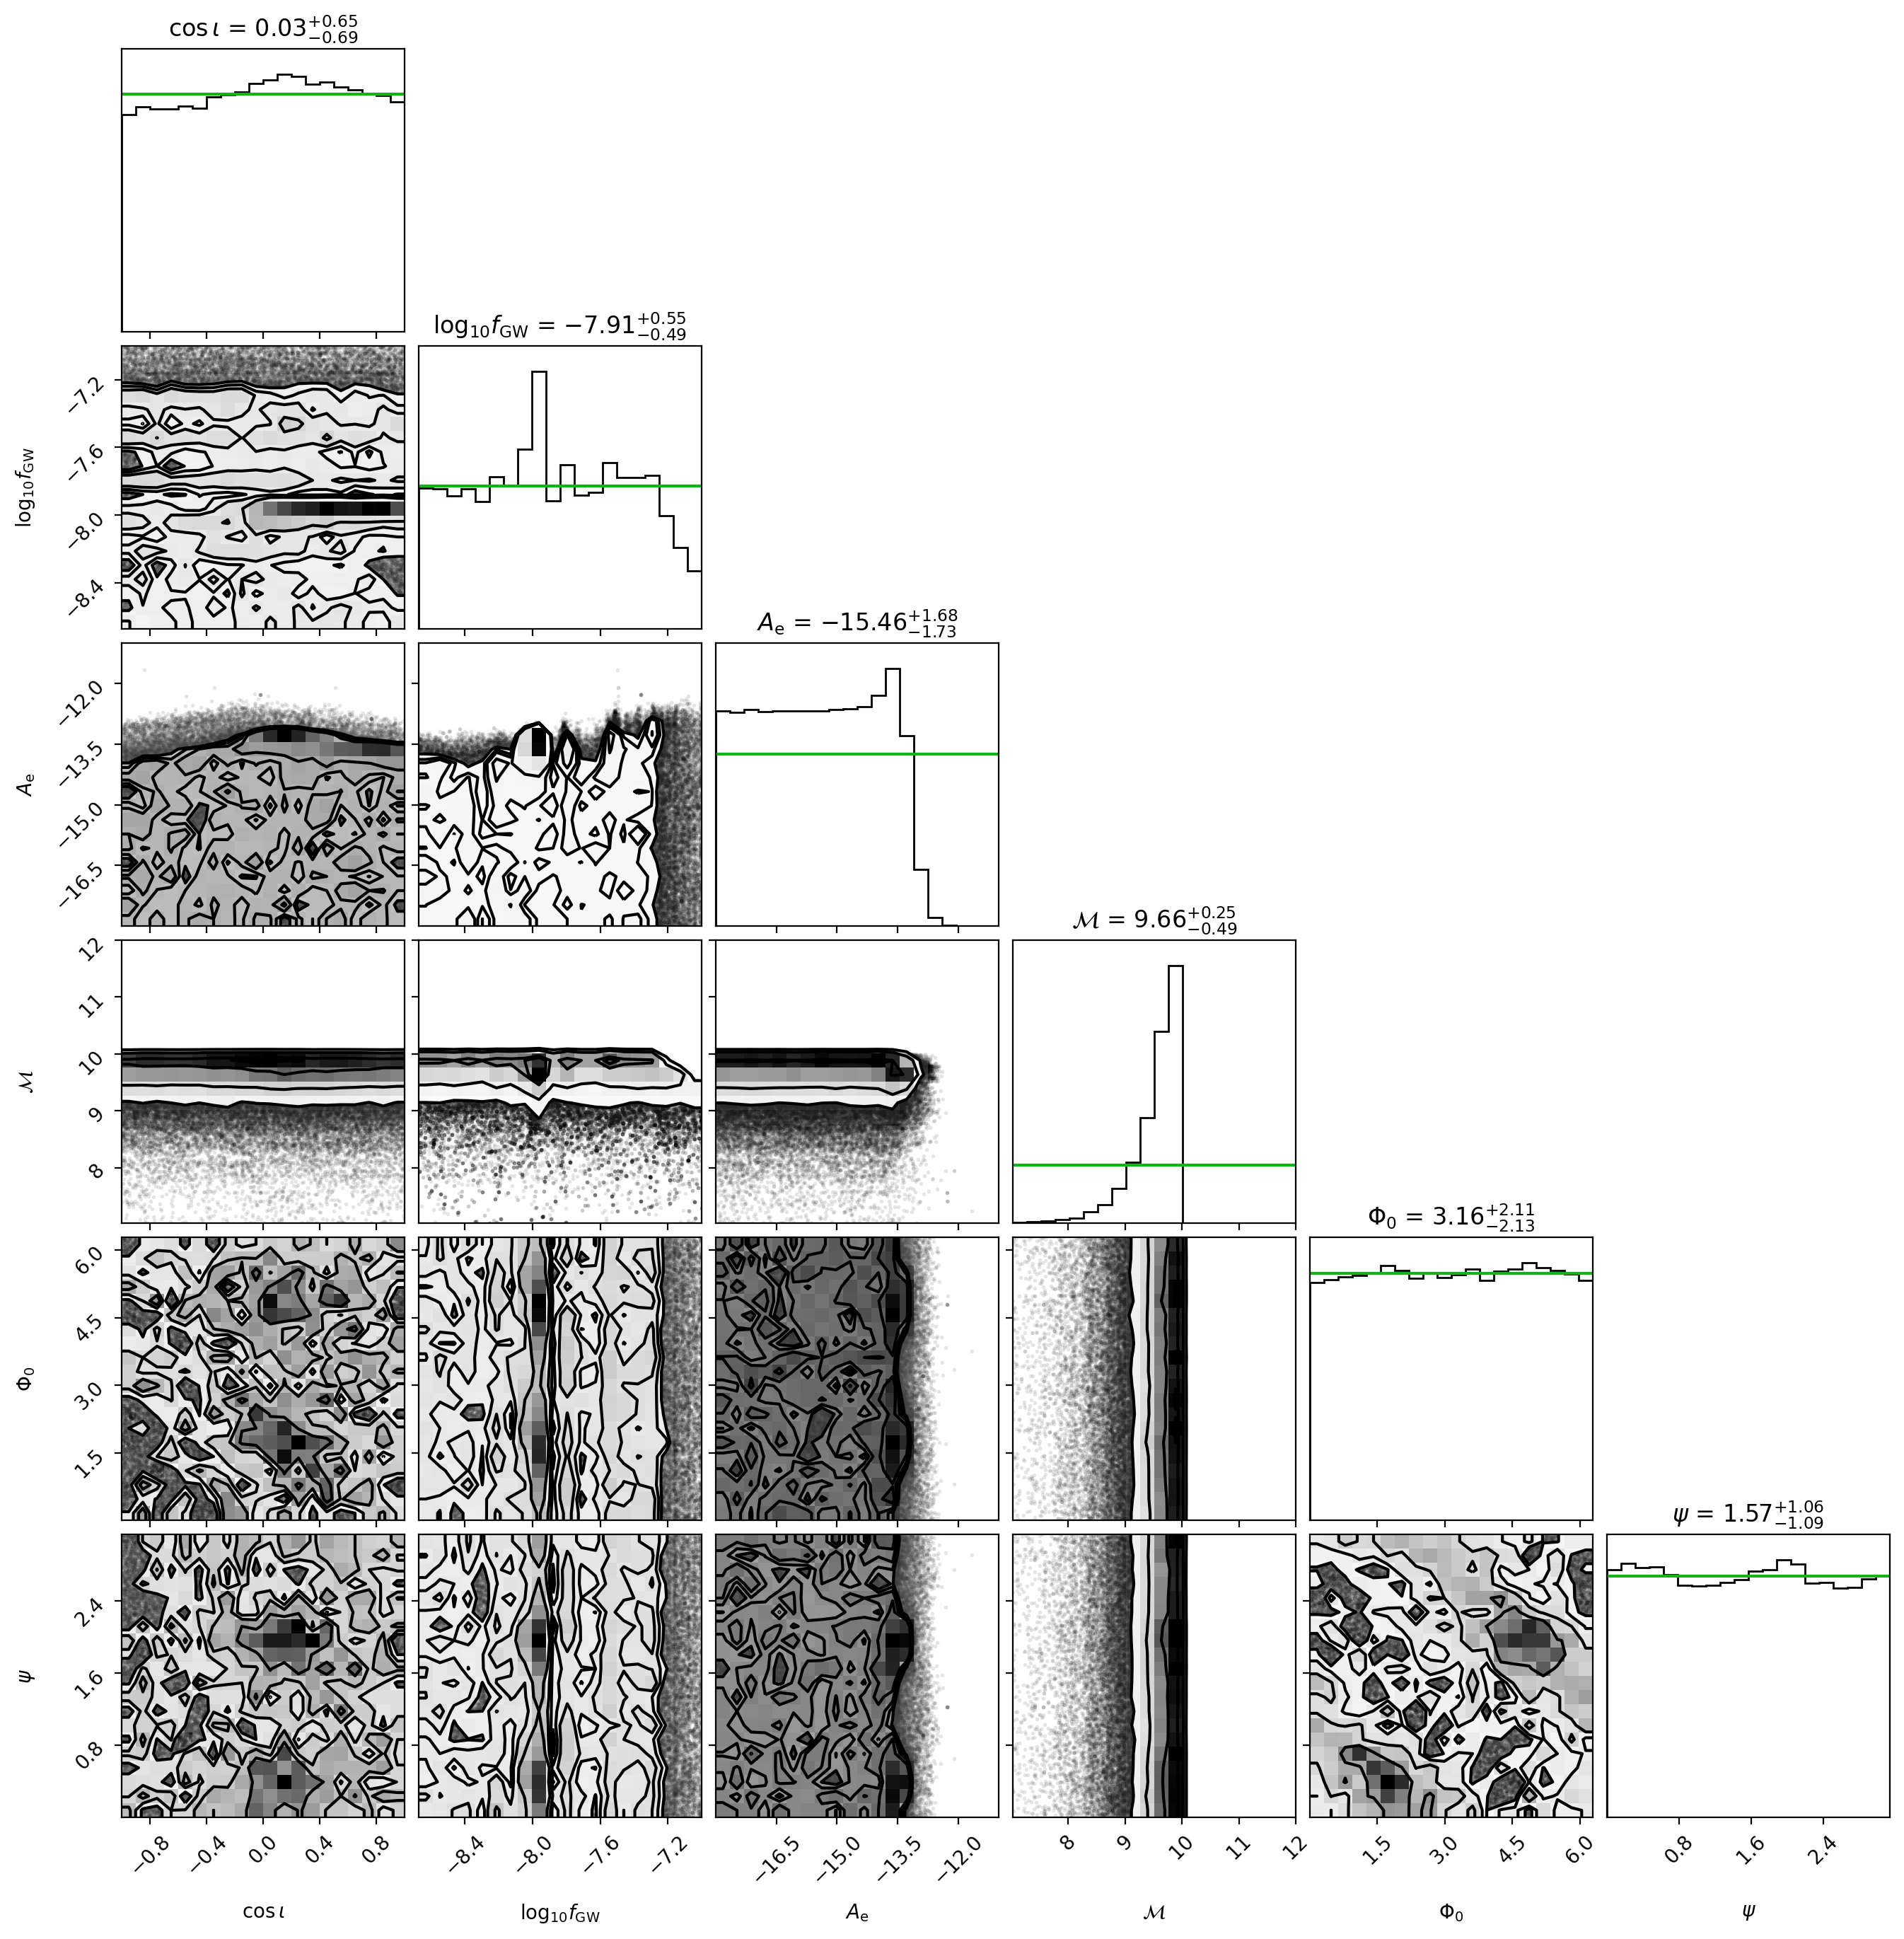

In [7]:
#corner plot of parameters common to all pulsars UNIFORM PRIOR

corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
labels = [r"$\cos \iota$", r"$\log_{10} f_{\rm GW}$",r"$A_{\rm e}$", r"$\cal M$", r"$\Phi_0$",r"$\psi$"]
par_keys = [ "0_cos_inc", "0_log10_fgw", "0_log10_h", "0_log10_mc", "0_phase0", "0_psi"]

burnin = 10
thin = 1000

#set ranges
ranges = [ (-1,1), (np.min(samples_cold[0][burnin::thin,3]),np.max(samples_cold[0][burnin::thin,3])),(np.min(samples_cold[0][burnin::thin,4]),-11), (np.min(samples_cold[0][burnin::thin,5]),12), (0,2*np.pi), (0,np.pi) ]

#set burnin and thinning

print("fGW",np.min(samples_cold[0][burnin::thin,3]))
truth = [xxx[key] for key in par_keys]

samples_cold_detect = np.vstack((
                          samples_cold[0][burnin::thin,1],
                          samples_cold[0][burnin::thin,3],
                          samples_cold[0][burnin::thin,4],
                          samples_cold[0][burnin::thin,5],
                          samples_cold[0][burnin::thin,6],
                          samples_cold[0][burnin::thin,7])).T

fig = corner.corner(samples_cold_detect, labels=labels, show_titles=True, # quantiles=[0.16, 0.5, 0.84],
                     range=ranges, hist_kwargs={"density":True}) #truths=truth,

#plot priors over 1D posteriors
for i, ax in enumerate(fig.axes):
    if i==0:#(len(labels)+1): #cos inc and cos theta
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0+1/2, color="xkcd:green")
    elif i==1*(len(labels)+1): #log10_fgw
        Xs = np.linspace(-9, -7)
        # Y = plot_Gaussian(Xs,np.log10(1.13e-8),1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/(np.max(samples_cold[0][burnin::thin,3]) - np.min(samples_cold[0][burnin::thin,3])), color="xkcd:green")
    elif i==2*(len(labels)+1): #log10_A
        #Xs = np.linspace(10**-18, 10**-11)     #amplitude
        Xs = np.linspace(np.min(samples_cold[0][burnin::thin,4]), -11)#np.max(samples_cold[0][burnin::thin,4]))
        ax.plot(Xs,Xs*0+(1/(np.max(samples_cold[0][burnin::thin,4]) - np.min(samples_cold[0][burnin::thin,4]))), color="xkcd:green")
        #ax.plot(Xs, Xs*0+1/7, color="xkcd:green")
    elif i==3*(len(labels)+1): #log10_M_ch
        Xs = np.linspace(np.min(samples_cold[0][burnin::thin,5]), 12)#np.max(samples_cold[0][burnin::thin,5]))
        # Y=plot_Gaussian(Xs,9.86,1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs,Xs*0+(1/(np.max(samples_cold[0][burnin::thin,5]) - np.min(samples_cold[0][burnin::thin,5]))), color="xkcd:green")
        #ax.plot(Xs, 10**(Xs*0+1/3), color="xkcd:green")
    elif i==4*(len(labels)+1): #gwphi and phase0
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0+1/(2*np.pi), color="xkcd:green")
    elif i==5*(len(labels)+1): #psi
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0+1/np.pi, color="xkcd:green")
        
#fig.suptitle('MDC__SMBHB_Source_and_GWB_G2D2_targetedfreq_detection (Without dL)', fontsize = 25);

[6.665324702494525e-01, -8.43, -13.668773493298787, 9.63, 0.24434609527920614, 1.1187560505283651]
hamp [4.68216156e-17 6.54390381e-15 4.68055795e-16 ... 1.88530688e-16
 1.10805276e-14 1.42553029e-18]
freq [3.5531254e-08 3.2580130e-09 4.3106898e-08 ... 2.5837814e-08 3.2350360e-09
 3.2350360e-09]
mc [2.3521434e+09 8.8878019e+09 9.2286147e+09 ... 8.3007251e+08 2.2533565e+09
 2.2533565e+09]
Length of logdL 99999999
required values 7.5595984 3.5531254e-08 2352143400.0 2.046871e-15
dL min 74.646
dL max 76.15400000000001
10**log10_d_L [5.7065094e+04 7.6107220e+02 6.3376957e+04 ... 2.0196935e+03 4.5433796e+01
 3.5315319e+05]
min 10**log10_d_L 7.008382e-05
max 10**log10_d_L 36274252.0
d_L_mask [     631     1858     3246 ... 99999352 99999807 99999945]
Sample shape (99999999, 9)
dL_mask length 150997
6
mc 7.0007167 9.995618


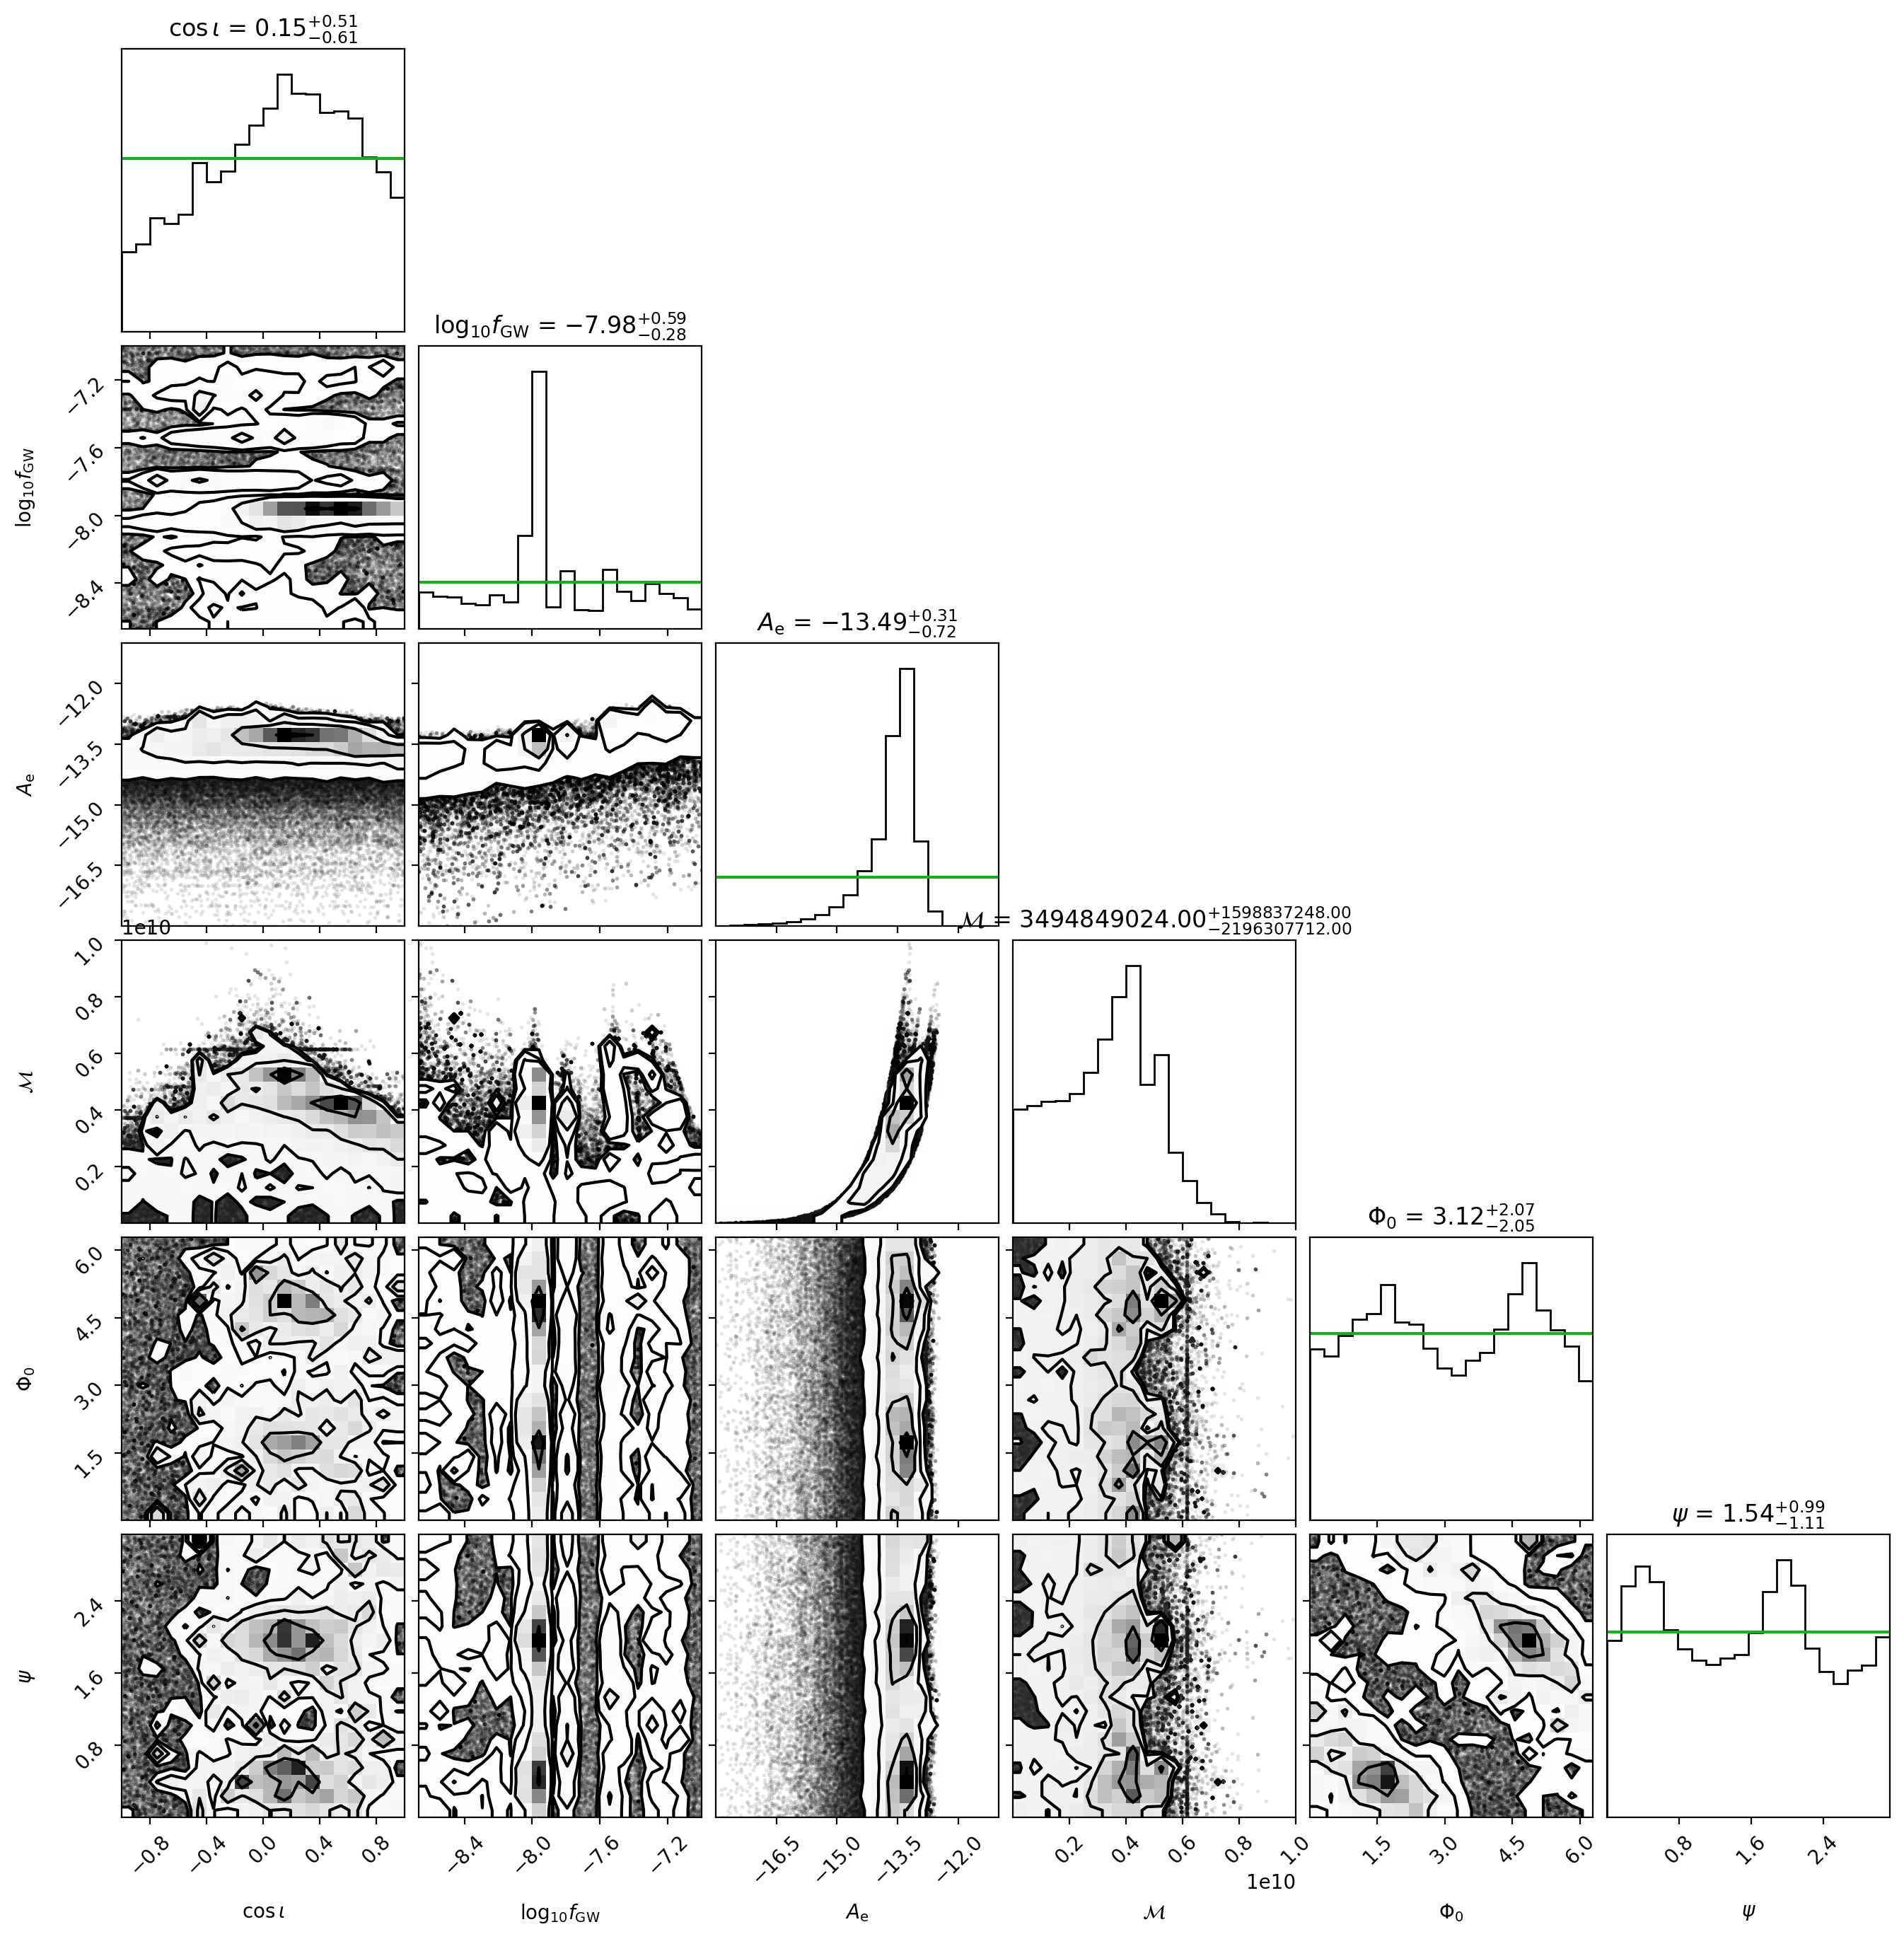

In [8]:
#corner plot of parameters common to all pulsars (Contains Luminosity distance)
corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
labels = [r"$\cos \iota$", r"$\log_{10} f_{\rm GW}$",r"$A_{\rm e}$", r"$\cal M$", r"$\Phi_0$",r"$\psi$"]
par_keys = [ "0_cos_inc",  "0_log10_fgw","0_log10_h", "0_log10_mc", "0_phase0", "0_psi"]

truth = [xxx[key] for key in par_keys]
print(truth)


#set burnin and thinning

burnin = 1
thin = 1

#set ranges
#ranges = [(-1,1),(np.min(samples_cold[0][burnin::thin,4]),np.max(samples_cold[0][burnin::thin,4])) , (np.min(samples_cold[0][burnin::thin,5]),np.max(samples_cold[0][burnin::thin,5])), (0,2*np.pi), (0,np.pi)]

#ranges = [ (-1,1), (-9,-7),(-18,-11), (7,12), (0,2*np.pi), (0,np.pi) ]

ranges = [ (-1,1), (-8.67,-7),(-18,-11), (10**7,10**10), (0,2*np.pi), (0,np.pi) ]


megaparsec = 3.086e+22 #meter
speed_of_light = 299792458.0 #m/s
T_sun = 1.327124400e20 / speed_of_light**3 #G*M_sun/c^3 = R_sun/c-->Sun time

############################################################################
h_amp = 10**samples_cold[0][burnin::thin,4]
fff = 10**samples_cold[0][burnin::thin,3]
mmm = 10**samples_cold[0][burnin::thin,5]

print('hamp',h_amp)
print('freq',fff)
print('mc',mmm)

log10_d_L = np.log10(2 * (mmm*T_sun)**(5/3) * (np.pi*fff)**(2/3) / h_amp *speed_of_light/megaparsec)
print("Length of logdL", len(log10_d_L))
print("required values",np.max(log10_d_L), fff[1000], mmm[1000], h_amp[1000] )
#####################################
d_L_percent_tolerance = 1.0
#####################################

d_L_min = target_d_L*(1-d_L_percent_tolerance/100)
d_L_max = target_d_L*(1+d_L_percent_tolerance/100)
print("dL min",d_L_min)
print("dL max",d_L_max)
print("10**log10_d_L",10**log10_d_L)
print("min 10**log10_d_L",np.min(10**log10_d_L))
print("max 10**log10_d_L",np.max(10**log10_d_L))

d_L_mask = np.where((10**log10_d_L>=d_L_min) & (10**log10_d_L<=d_L_max))[0]
print("d_L_mask",d_L_mask)


samples2plot = np.concatenate((samples_cold[0][burnin::thin,corner_mask], np.array([log10_d_L,]).T), axis=1)

print("Sample shape", samples2plot.shape)
print("dL_mask length", len(d_L_mask))
print(len(ranges))

samples2plot_detect = np.vstack((
                          samples2plot[d_L_mask,1],
                          samples2plot[d_L_mask,3],
                          samples2plot[d_L_mask,4],
                          10**samples2plot[d_L_mask,5],
                          samples2plot[d_L_mask,6],
                          samples2plot[d_L_mask,7])).T

print("mc", np.min(samples2plot[d_L_mask,5]), np.max(samples2plot[d_L_mask,5]))
fig = corner.corner(samples2plot_detect,
                    labels=labels,
                    show_titles=True, 
                    range=ranges, hist_kwargs={"density":True},truth_color='red') #truths=truth,

#quantiles=[0.16, 0.5, 0.84],

#plot priors over 1D posteriors
for i, ax in enumerate(fig.axes):
    if i==0:#(len(labels)+1): #cos inc and cos theta
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0+1/2, color="xkcd:green")
    elif i==1*(len(labels)+1): #log10_fgw
        Xs = np.linspace(-9, -7)
        # Y = plot_Gaussian(Xs,np.log10(1.13e-8),1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/(np.max(samples2plot[d_L_mask,3]) - np.min(samples2plot[d_L_mask,3])), color="xkcd:green")
    elif i==2*(len(labels)+1): #log10_A
        #Xs = np.linspace(10**-18, 10**-11)     #amplitude
        Xs = np.linspace(np.min(samples2plot[d_L_mask,4]), -11)#np.max(samples_cold[0][burnin::thin,4]))
        ax.plot(Xs,Xs*0+(1/(np.max(samples2plot[d_L_mask,4]) - np.min(samples2plot[d_L_mask,4]))), color="xkcd:green")
        #ax.plot(Xs, Xs*0+1/7, color="xkcd:green")
    elif i==3*(len(labels)+1): #log10_M_ch
        Xs = np.linspace(np.min(samples2plot[d_L_mask,5]), 12)#np.max(samples_cold[0][burnin::thin,5]))
        # Y=plot_Gaussian(Xs,9.86,1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs,Xs*0+(1/(np.max(samples2plot[d_L_mask,5]) - np.min(samples2plot[d_L_mask,5]))), color="xkcd:green")
        #ax.plot(Xs, 10**(Xs*0+1/3), color="xkcd:green")
    elif i==4*(len(labels)+1): #gwphi and phase0
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0+1/(2*np.pi), color="xkcd:green")
    elif i==5*(len(labels)+1): #psi
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0+1/np.pi, color="xkcd:green")

7.0007167e+00
9.995618


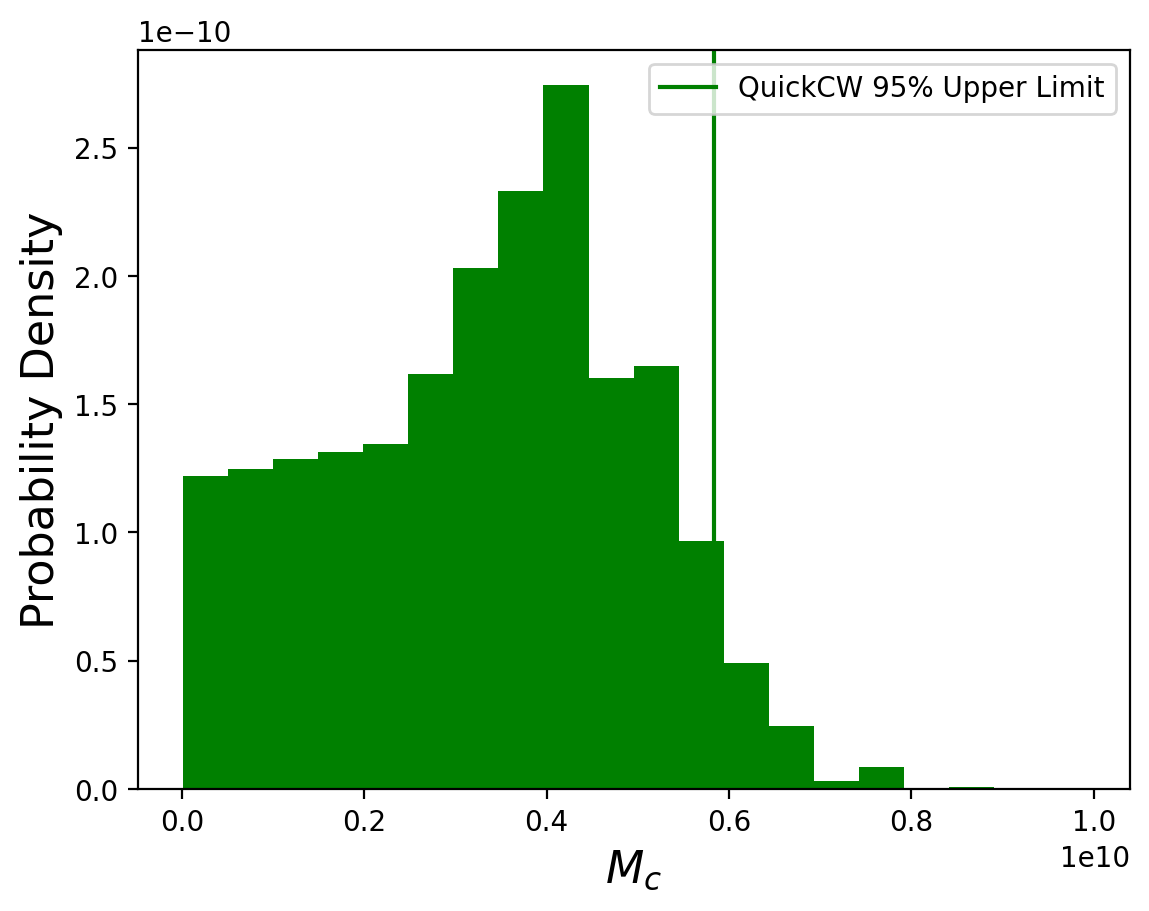

5.838170214399944
9.766276752881696
9.766276752881696


In [9]:
#dL Mc Upper limit

logMcmin_dL = np.min(samples2plot[d_L_mask,5])
logMcmax_dL = np.max(samples2plot[d_L_mask,5])

#print(samples2plot[d_L_mask,5])
#print(np.power(10,samples2plot[d_L_mask,5]))

print(logMcmin_dL)
print(logMcmax_dL)

plt.hist(np.power(10,samples2plot[d_L_mask,5]), bins=20, density=True,color='green')
#plt.hist(bjorn_UL, bins=20, density=True,color='blue', alpha = 0.5)
plt.axvline(x = 5838170214.399944,color='green',label= "QuickCW 95% Upper Limit")
#plt.axvline(x = 5539651847.030904,color='blue',label= "Enterprise 95% Upper Limit")
#plt.title("NGC3115 Upper Limit Mc histogram (with dL masking)", y=1.05)
plt.xlabel("$M_c$",fontsize = 16)
plt.ylabel("Probability Density", fontsize = 16)
plt.legend(loc='upper right')
plt.show()

x = np.quantile(np.power(10,samples2plot[d_L_mask,5]), 0.95)
print(x/1e9)
print(np.log10(x))
#y = np.quantile(bjorn_UL, 0.95)
#print(y/1e9)
print(np.log10(x))

In [10]:
fmax=np.max(10**samples2plot[d_L_mask,3])
fmin=np.min(10**samples2plot[d_L_mask,3])

T = 2.11E-9
bins = fmax-fmin
print(bins/T)
print(fmax,fmin)
print(T*46)

46.38393681782213
9.9988036e-08 2.1179296e-09


In [11]:
print(samples2plot[d_L_mask,3][10])

-8.021696


In [12]:
T = 2.11E-9  # Step size for vals
fmax = np.max(10 ** samples2plot[d_L_mask, 3])  # Maximum value from your data
fmin = np.min(10 ** samples2plot[d_L_mask, 3])  # Minimum value from your data

# Create a list of values starting from fmin and incrementing by T until fmax
vals = []
while fmin < fmax:
    vals.append(fmin)
    fmin += T

# Print the length of vals for debugging (optional)
#print(len(vals) - 1)
#print(vals[0],vals[1])
# Find the indices in samples2plot[d_L_mask, 3] that are between consecutive values in vals
indices = []
inc = 0
for i, value in enumerate(10 ** samples2plot[d_L_mask, 3]):
    # Make sure that inc + 1 is a valid index in vals
    if inc < len(vals)-1:
        #print(inc)
        if vals[inc] >= value and value <=vals[inc+1]:
            #print(value)
            indices.append(i)
        inc += 1  # Increment inc only when condition is met
    else:
        break  # Exit the loop once you've processed all values in vals

# Output the indices
#print(indices)


In [13]:
#WORKS PROPERLY (DONT DELETE!!)
def calculate_mc(inc):
    
    
    T = 2.11E-9
    fmax=np.max(10**samples2plot[d_L_mask,3])
    fmin=np.min(10**samples2plot[d_L_mask,3])


    vals = []
    while fmin < fmax:
        #print(fmin)  # Round to 1 decimal place for better formatting
        vals.append(fmin)
        fmin += T

    indices=[]
    for i, value in enumerate(10**samples2plot[d_L_mask,3]):
        #print("at inc "+str(inc) +" I have " + str(i))
        if  value >= vals[inc] and value <=vals[inc+1]:
            #print ("MY VALUE "+str(value)+" is between "+str(vals[inc])+" and "+str(vals[inc+1]))
            indices.append(i)
        #inc += 1  # Increment inc only when condition is met 
    #print(indices)


    data_list= [10**samples2plot[d_L_mask[i],5] for i in indices]
    #print(len(data_list))
    return data_list


In [14]:
#WORKS PROPERLY (DONT DELETE!!)

arr = []

for i in range(0,46):
    arr.append(calculate_mc(i))

arr_len=[]
for i in range(0,46):
    arr_len.append(len(arr[i]))
#print(arr)
print(arr_len)
#plt.plot(fGW_vals,arr_len)




[18624, 9505, 6825, 43271, 13393, 3167, 8194, 2135, 1355, 1319, 1414, 1440, 3654, 5154, 1813, 1335, 2576, 709, 2179, 1103, 679, 967, 841, 2403, 2029, 1678, 1524, 1189, 844, 665, 587, 989, 1216, 686, 490, 594, 790, 410, 602, 301, 359, 462, 387, 280, 261, 457]


In [15]:
UL = []


for i in range(0,46):
    x = np.quantile(arr[i], 0.95)
    UL.append(x)
    
print(UL)
print(np.log10(UL))
print(len(UL))




[6913072872.993876, 5704241834.40141, 4580795973.268406, 5490110784.015089, 5093686402.076671, 4373384306.741153, 5102642513.575119, 4490415512.724785, 3731874846.1157393, 3820875238.310937, 3765418859.254546, 4742978323.506979, 5878481758.335102, 6418113294.856741, 6535287560.914986, 5855986400.910385, 5555197172.978586, 6301226998.313587, 5764039240.014212, 4555919183.935792, 4970309995.172188, 6639814592.193128, 5451044898.879082, 6514111248.445826, 5343233876.933728, 5122083318.366527, 4801804139.976335, 4362967238.705019, 5957455831.834591, 5476781195.203684, 5094610366.796526, 4942801954.961848, 4239385713.77178, 5129875790.35977, 4816447824.650003, 4231547130.4124136, 4152311704.0855227, 3943166223.0739026, 3704270540.445232, 3648278742.5486135, 3303824852.737284, 3771583966.470869, 3074171690.4262533, 3199250610.414171, 3218766524.8088107, 3046544764.1838107]
[9.83967113 9.75619793 9.66094095 9.73958111 9.7070322  9.64081764
 9.70779514 9.65228653 9.57192707 9.58216286 9.575813

In [16]:
def UL_error_calc(n):
    global arr
    global UL
    counts, bin_edges, _ =plt.hist(arr[n], density=True)
    plt.axvline(x=UL[n],color='black')#,label= "15yr Upper Limit = 2.89e+10")
    #plt.axvline(x = 1.34e+09,color='red',label= "12.5yr Upper Limit = 1.34e+09 ")
    
    bin_index = np.digitize(UL[n], bin_edges) - 1  # -1 because digitize returns index starting from 1
    #print(bin_index)
    # Get the corresponding y value (the count in the appropriate bin)
    
    if bin_index < len(counts):
        y_value = counts[bin_index]
        #print(y_value)
    else:
        #print(f"Warning: bin_index {bin_index} is out of bounds.")
        y_value = 0  # Set to a default value or handle as needed
    
    '''
    y_value = counts[bin_index]
    #print('y_value',y_value.shape)
    '''
    sigma = np.sqrt((.95*.05)/len(arr[n]))/y_value
    #print(len(arr[n]))
    return sigma

In [17]:

T = 2.11E-9
fmax=np.max(10**samples2plot[d_L_mask,3])
fmin=np.min(10**samples2plot[d_L_mask,3])


vals = []
while fmin < fmax:
    #print(fmin)  # Round to 1 decimal place for better formatting
    vals.append(fmin)
    fmin += T
    
print(vals)


[2.1179296e-09, 4.227929609468661e-09, 6.337929609468661e-09, 8.447929609468662e-09, 1.0557929609468662e-08, 1.2667929609468662e-08, 1.4777929609468663e-08, 1.6887929609468663e-08, 1.8997929609468664e-08, 2.1107929609468664e-08, 2.3217929609468664e-08, 2.5327929609468665e-08, 2.7437929609468665e-08, 2.9547929609468665e-08, 3.1657929609468666e-08, 3.376792960946866e-08, 3.587792960946866e-08, 3.798792960946866e-08, 4.0097929609468654e-08, 4.220792960946865e-08, 4.431792960946865e-08, 4.6427929609468645e-08, 4.853792960946864e-08, 5.064792960946864e-08, 5.2757929609468636e-08, 5.4867929609468633e-08, 5.697792960946863e-08, 5.908792960946863e-08, 6.119792960946863e-08, 6.330792960946863e-08, 6.541792960946863e-08, 6.752792960946862e-08, 6.963792960946862e-08, 7.174792960946862e-08, 7.385792960946861e-08, 7.596792960946861e-08, 7.807792960946861e-08, 8.01879296094686e-08, 8.22979296094686e-08, 8.44079296094686e-08, 8.65179296094686e-08, 8.862792960946859e-08, 9.073792960946859e-08, 9.28479

In [18]:
UL_vals = [6913072872.993876, 5704241834.40141, 4580795973.268406, 5490110784.015089, 
           5093686402.076671, 4373384306.741153, 5102642513.575119, 4490415512.724785, 
           3731874846.1157393, 3820875238.310937, 3765418859.254546, 4742978323.506979, 
           5878481758.335102, 6418113294.856741, 6535287560.914986, 5855986400.910385, 
           5555197172.978586, 6301226998.313587, 5764039240.014212, 4555919183.935792, 
           4970309995.172188, 6639814592.193128, 5451044898.879082, 6514111248.445826, 
           5343233876.933728, 5122083318.366527, 4801804139.976335, 4362967238.705019, 5957455831.834591, 
           5476781195.203684, 5094610366.796526, 4942801954.961848, 4239385713.77178, 5129875790.35977, 
           4816447824.650003, 4231547130.4124136, 4152311704.0855227, 3943166223.0739026, 3704270540.445232, 
           3648278742.5486135, 3303824852.737284, 3771583966.470869, 3074171690.4262533, 3199250610.414171, 
           3218766524.8088107, 3046544764.1838107]
           
           

fGW_vals = [ 4.227929609468661e-09, 6.337929609468661e-09, 8.447929609468662e-09, 
        1.0557929609468662e-08, 1.2667929609468662e-08, 1.4777929609468663e-08, 1.6887929609468663e-08, 
        1.8997929609468664e-08, 2.1107929609468664e-08, 2.3217929609468664e-08, 2.5327929609468665e-08, 
        2.7437929609468665e-08, 2.9547929609468665e-08, 3.1657929609468666e-08, 3.376792960946866e-08, 
        3.587792960946866e-08, 3.798792960946866e-08, 4.0097929609468654e-08, 4.220792960946865e-08,
        4.431792960946865e-08, 4.6427929609468645e-08, 4.853792960946864e-08, 5.064792960946864e-08, 
        5.2757929609468636e-08, 5.4867929609468633e-08, 5.697792960946863e-08, 5.908792960946863e-08,
        6.119792960946863e-08, 6.330792960946863e-08, 6.541792960946863e-08, 6.752792960946862e-08, 
        6.963792960946862e-08, 7.174792960946862e-08, 7.385792960946861e-08, 7.596792960946861e-08, 
        7.807792960946861e-08, 8.01879296094686e-08, 8.22979296094686e-08, 8.44079296094686e-08, 
        8.65179296094686e-08, 8.862792960946859e-08, 9.073792960946859e-08, 9.284792960946859e-08, 
        9.495792960946858e-08, 9.706792960946858e-08, 9.917792960946858e-08]

UL_error = [30012097.53373951, 57757499.765138105, 
            35056528.72239883, 5634608.4581706915, 22476279.257132925, 
            67653504.83468825, 21138975.46690373, 38029494.23722958, 152432397.46657068, 
            64477891.67527569, 174119761.3537525, 44663352.73388931, 15046314.483537065, 
            6837287.484643934, 38715261.91189148, 17030514.617107864, 22886705.759398192, 
            94660864.51204476, 6066277.618028905, 91365124.46900447, 227782200.89492238, 
            67073917.8836657, 23051549.58434837, 12420888.203547781, 13891155.330419336, 27203544.305843756, 
            177101117.36312494, 20740356.45823164, 86249906.00211617, 80672333.11156608, 59672222.288011834, 
            174657985.26067275, 55032881.24385157, 37343084.15300023, 54850039.21055238, 30888120.794699706, 
            12567616.31065211, 36370534.75401545, 75338878.31251843, 95323981.15610823, 76297716.77310635, 
            0, 68712413.41581695, 68792780.52433798, 41516336.22070998, 34724523.258089855]

print((4.227929609468661+6.337929609468661)/2)
print(5.2829296094686615-4.227929609468661)

 #2.1179296e-09,
plt.figure(figsize=(8,6))

#plt.scatter(fGW_vals,UL_vals)

fGW_plot = []

for i in fGW_vals:
    fGW_plot.append(i-1.0550000000000006e-09)
    
#print(fGW_plot)

UL_by9 = []
for i in UL_vals:
    UL_by9.append(i/1e9)

ULerr_by9 = []
for i in UL_error:
    ULerr_by9.append(i/1e9)
    
print(np.log10(ULerr_by9))




#plt.hist(arr_len, bins=30)#, cmap='Blues')
#print(arr_len)
#print(UL_by9)
'''
plt.errorbar(np.log10(fGW_plot),UL_by9, yerr=(ULerr_by9), fmt='o', color='b', 
             ecolor='b', elinewidth=2, capsize=3, capthick=2,linestyle='-')
             
plt.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
plt.xlabel('$log_{10}(f_{GW})$', fontsize = 20)
plt.ylabel('$log_{10}(M_c)$', fontsize = 20)
#plt.xlim(np.min(vals), np.max(vals))
#plt.title("$M_c$ upper limit vs $f_{GW}$ plot with 47 bins")
'''

5.2829296094686615
1.0550000000000006
[-1.52270365 -1.23839161 -1.45523109 -2.24913626 -1.64827558 -1.1697097
 -1.67491607 -1.41987945 -0.81692272 -1.19058917 -0.75915194 -1.35004868
 -1.82256987 -2.16511616 -1.4121178  -1.76877223 -1.64041671 -1.02382953
 -2.21707772 -1.03921955 -0.64248022 -1.17344633 -1.63729987 -1.90584735
 -1.85726163 -1.56537451 -0.7517787  -1.68318378 -1.06424137 -1.09327538
 -1.22422779 -0.75781155 -1.25937775 -1.42778982 -1.26082306 -1.51020851
 -1.90074709 -1.43925031 -1.12298085 -1.02079783 -1.11748846        -inf
 -1.1629648  -1.16245714 -1.38178098 -1.45936371]


<ipython-input-18-ce217a4be0c9>:63: RuntimeWarning: divide by zero encountered in log10
  print(np.log10(ULerr_by9))


'\nplt.errorbar(np.log10(fGW_plot),UL_by9, yerr=(ULerr_by9), fmt=\'o\', color=\'b\', \n             ecolor=\'b\', elinewidth=2, capsize=3, capthick=2,linestyle=\'-\')\n             \nplt.ticklabel_format(style=\'sci\', axis=\'both\', scilimits=(0,0))\nplt.xlabel(\'$log_{10}(f_{GW})$\', fontsize = 20)\nplt.ylabel(\'$log_{10}(M_c)$\', fontsize = 20)\n#plt.xlim(np.min(vals), np.max(vals))\n#plt.title("$M_c$ upper limit vs $f_{GW}$ plot with 47 bins")\n'

<Figure size 800x600 with 0 Axes>

<ipython-input-19-384edfb5a290>:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.ax.set_xticklabels(['10','$10^2$','$10^3$','$10^4$','$10^5$'])  # horizontal colorbar


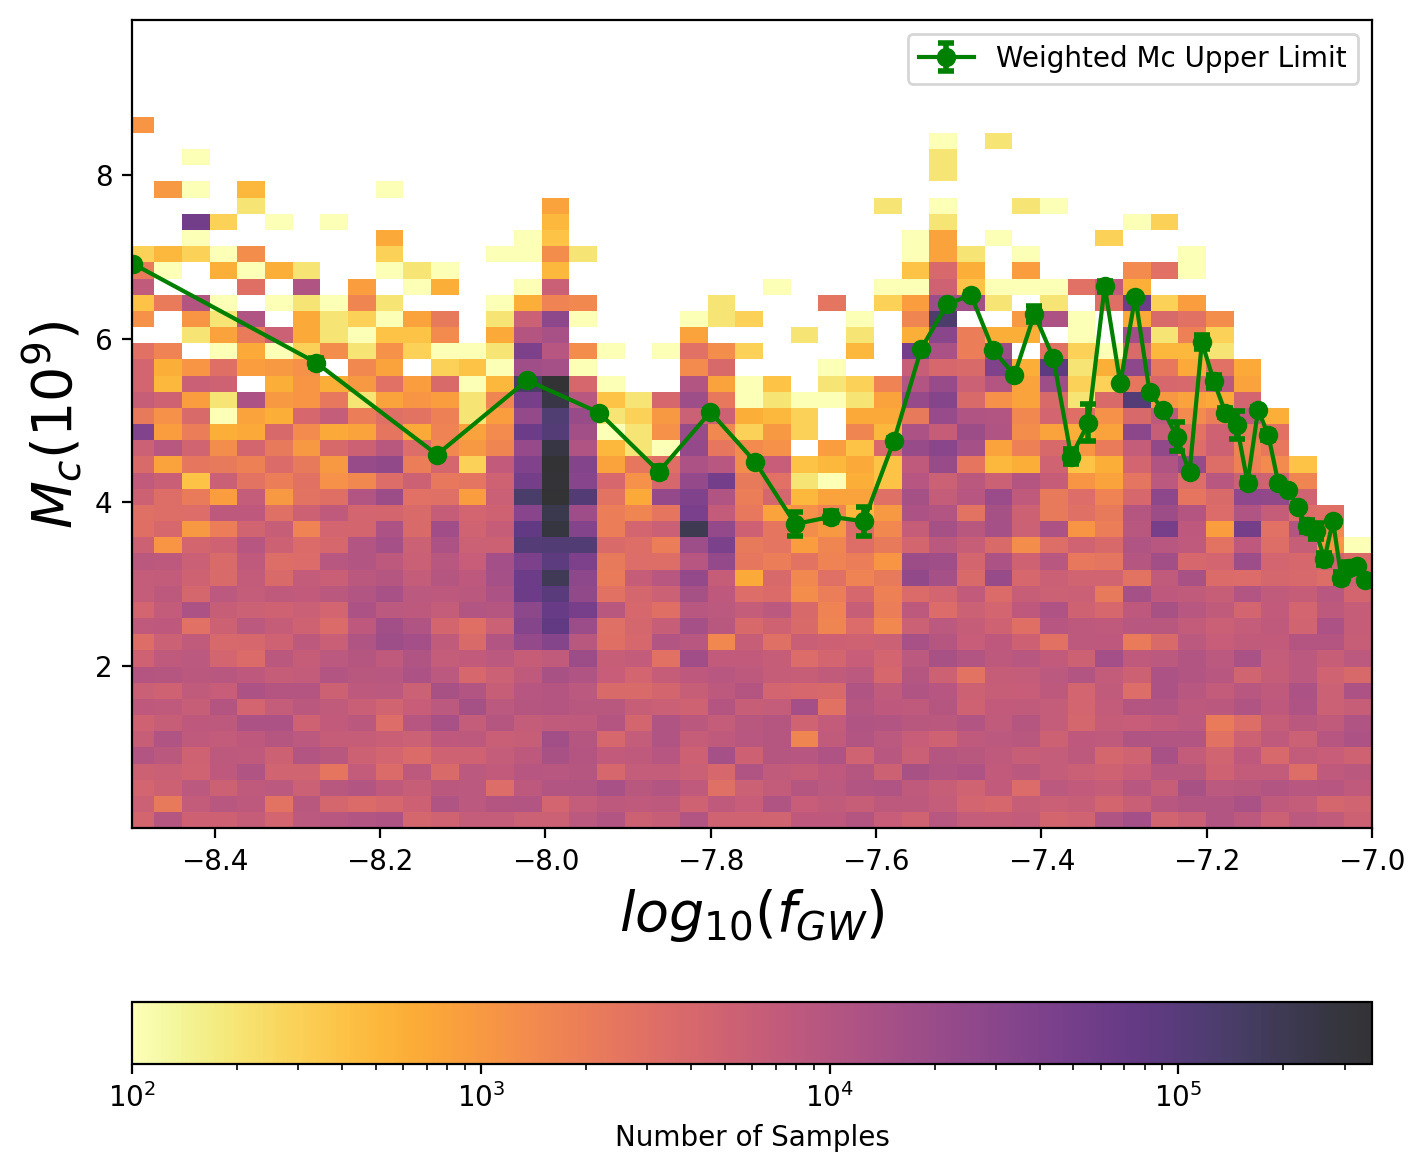

In [19]:
from matplotlib import colors
fig, ax = plt.subplots(figsize=(8,7.5))
counts,xbins,ybins,image = ax.hist2d(samples2plot[d_L_mask,3], (10**samples2plot[d_L_mask,5])/1e9, bins=50, 
                                     norm=colors.LogNorm(), alpha = 0.8, cmap = 'inferno_r')
#ax.plot(np.log10(fGW_plot),np.log10(UL_vals))
ax.errorbar(np.log10(fGW_plot),UL_by9, yerr=ULerr_by9, fmt='o', color='g', 
             ecolor='green', elinewidth=2, capsize=3, capthick=2,linestyle='-',label = 'Weighted Mc Upper Limit')

cbar = plt.colorbar(image, ax = ax, label='Number of Samples', orientation='horizontal')
cbar.ax.set_xticklabels(['10','$10^2$','$10^3$','$10^4$','$10^5$'])  # horizontal colorbar

plt.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
plt.xlim(-8.5,-7)
plt.xlabel('$log_{10}(f_{GW})$', fontsize = 20)
plt.ylabel('$M_c (10^9)$', fontsize = 20)
plt.legend(fontsize = 10)
